In [29]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [30]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [58]:
INPUT_PATH = '/content/drive/MyDrive/y3s2/SRIP'

In [150]:
df = pd.read_parquet(os.path.join(INPUT_PATH, 'data/Cohort2510_with_features.parquet'))
weekly_activity = pd.read_parquet(os.path.join(INPUT_PATH, 'data/weekly_activity.parquet'))
students_df = pd.read_csv(os.path.join(INPUT_PATH, 'csvs from posthog/Students.csv'))
assignments_df = pd.read_parquet(os.path.join(INPUT_PATH, 'data/assignments.parquet'))

## Filtering `students_df`

`df` & `weekly_activity` are separated by cohort : Filter `students_df` to only include students who are found in those dataframes.

In [151]:
unique_distinct_ids_in_df = df['distinct_id'].unique()
students_df = students_df[students_df['distinct_id'].isin(unique_distinct_ids_in_df)]
students_df.sort_values(by='distinct_id')

,name,distinct_id
12,AshleyGohYuTing,26
6,BansalNaman,28
11,BennettHoChengXun,29
10,ChanEugene,30
4,ChiaChengXuXavier,31
45,ChowdhuryTia,32
42,DishaShivaraman,33
44,EthanDhirenDivyanathan,34
16,GuoRuiTing,35
7,GuptaNavya,36


## 1. Plotting per-student activity (session count && session duration)

The function `plot_student_activity` takes a `distinct_id` as input and generates a dual-axis chart. For the student with that `distinct_id`, the chart displays total session count and average session duration across each course week.


In [152]:
def plot_student_activity(distinct_id_to_plot):
  student_data = weekly_activity[weekly_activity['distinct_id'] == distinct_id_to_plot]

  if student_data.empty:
      print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
      return

  student_name = distinct_id_to_plot
  if ('name' in student_data.columns):
    student_name = student_data['name'].iloc[0]

  ## Sort by course_week (just in case)
  student_data = student_data.sort_values('course_week')

  fig, ax1 = plt.subplots(figsize=(12, 7))

  ## Average session duration on the first y-axis (left)
  ax1.bar(student_data['course_week'].astype(str), student_data['avg_weekly_duration'], color='blue', alpha=0.7, label='Average Session Duration (s)')
  ax1.set_xlabel('Course Week')
  ax1.set_ylabel('Average Session Duration (seconds)', color='skyblue')
  ax1.tick_params(axis='y', labelcolor='skyblue')
  ax1.set_title(f'Student {student_name}: Average Session Duration and Session Count per Course Week')
  ax1.set_xticklabels(student_data['course_week'].astype(str), rotation=45, ha='right')

  ## Session count on the second y-axis (right)
  ax2 = ax1.twinx()
  ax2.plot(student_data['course_week'].astype(str), student_data['weekly_session_count'], color='red', marker='o', linestyle='-', label='Session Count')
  ax2.set_ylabel('Session Count', color='red')
  ax2.tick_params(axis='y', labelcolor='red')

  fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

  fig.tight_layout()
  plt.show()


List of available students:
                       name  distinct_id
12         AshleyGohYuTing           26
6              BansalNaman           28
11       BennettHoChengXun           29
10              ChanEugene           30
4        ChiaChengXuXavier           31
45            ChowdhuryTia           32
42         DishaShivaraman           33
44  EthanDhirenDivyanathan           34
16              GuoRuiTing           35
7               GuptaNavya           36
13            IanTayQiShen           37
15         JoshuaSimJunHui           38
0                  KimAmin           39
43             KimYongchan           40
3              KongXinYang           41
1                LeeJaeYan           42
46             LimJingYuan           43
8               LinBo-Ruei           44
47          MarcusWeeYuZhe           45
2               NgYeeXiang           46
5                RenZhaoyi           47
14       SatapathyPulastya           48
9            SeetohYihKeet           49
17         

/tmp/ipykernel_6782/1174131133.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(student_data['course_week'].astype(str), rotation=45, ha='right')


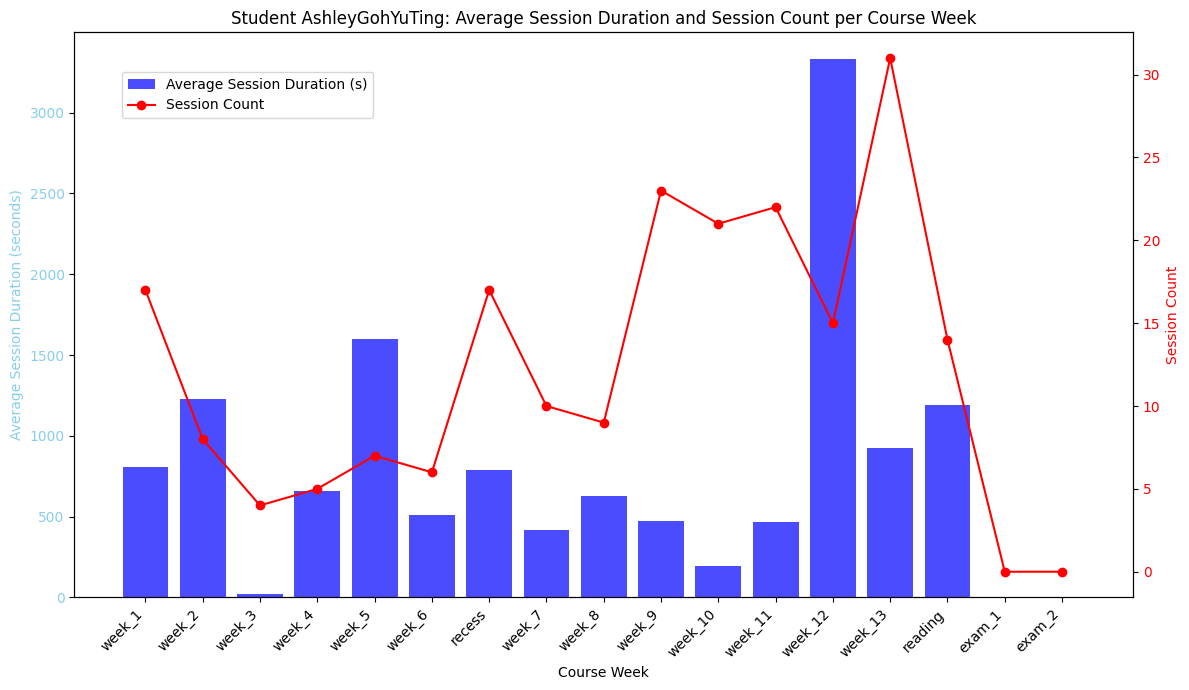

In [154]:
print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
id = input("ID of student to plot: ")
plot_student_activity(int(id))

## 2. Activity Trends Around Due Dates

The function `plot_due_date_activity` takes a `distinct_id` as input and visualizes how the student's activity (average session duration and session count) changes in relation to the number of days from an exercise/paper due date.
- Exercises' maximum gap : 19 days
- Papers' maximum gap : 27 days

In [155]:
def plot(df_due_date_activity, student_name, col, assignment_type):
  ## Group by col (days_to_exercise_due OR days_to_paper_due)
  due_date_summary = df_due_date_activity.groupby(col).agg(
      avg_session_duration=('study_session_duration', 'mean'),
      total_session_count=('study_session_id', 'nunique')
  ).reset_index()

  ## Sort by col for chronological plotting
  due_date_summary = due_date_summary.sort_values(col)

  all_days = range(int(df_due_date_activity[col].min()), int(df_due_date_activity[col].max()) + 1)
  due_date_summary = (
      due_date_summary
      .set_index(col)
      .reindex(all_days, fill_value=0)
      .rename_axis(col)
      .reset_index()
  )

  fig, ax1 = plt.subplots(figsize=(14, 7))

  ## Average session duration on the first y-axis (left)
  ax1.bar(due_date_summary[col], due_date_summary['avg_session_duration'], color='lightcoral', alpha=0.7, label='Average Session Duration (s)')
  ax1.set_xlabel(f'Days from {assignment_type} Due Date')
  ax1.set_ylabel('Average Session Duration (seconds)', color='lightcoral')
  ax1.tick_params(axis='y', labelcolor='lightcoral')
  ax1.set_title(f'Student {student_name}: Activity Relative to {assignment_type} Due Date')

  ## Session count on the second y-axis (right)
  ax2 = ax1.twinx()
  ax2.plot(due_date_summary[col], due_date_summary['total_session_count'], color='darkgreen', marker='s', linestyle='--', label='Total Session Count')
  ax2.set_ylabel('Total Session Count', color='darkgreen')
  ax2.tick_params(axis='y', labelcolor='darkgreen')

  ## Add vertical line at 0 (due date)
  ax1.axvline(x=0, color='gray', linestyle=':', linewidth=2, label='Due Date')

  lines, labels = ax1.get_legend_handles_labels()
  lines2, labels2 = ax2.get_legend_handles_labels()
  ax2.legend(lines + lines2, labels + labels2, loc='upper left')

  fig.tight_layout()
  plt.grid(True, linestyle='--', alpha=0.6)
  plt.show()


def plot_due_date_activity(distinct_id_to_plot):
  student_data = df[df['distinct_id'] == distinct_id_to_plot]

  if student_data.empty:
      print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
      return

  student_name = distinct_id_to_plot
  if ('name' in student_data.columns):
    student_name = student_data['name'].iloc[0]

  ## Plotting days to exercise due date
  plot(student_data, student_name, 'days_to_exercise_due', 'Exercise')
  ## Plotting days to paper due date
  plot(student_data, student_name, 'days_to_paper_due', 'Paper')


List of available students:
                       name  distinct_id
12         AshleyGohYuTing           26
6              BansalNaman           28
11       BennettHoChengXun           29
10              ChanEugene           30
4        ChiaChengXuXavier           31
45            ChowdhuryTia           32
42         DishaShivaraman           33
44  EthanDhirenDivyanathan           34
16              GuoRuiTing           35
7               GuptaNavya           36
13            IanTayQiShen           37
15         JoshuaSimJunHui           38
0                  KimAmin           39
43             KimYongchan           40
3              KongXinYang           41
1                LeeJaeYan           42
46             LimJingYuan           43
8               LinBo-Ruei           44
47          MarcusWeeYuZhe           45
2               NgYeeXiang           46
5                RenZhaoyi           47
14       SatapathyPulastya           48
9            SeetohYihKeet           49
17         

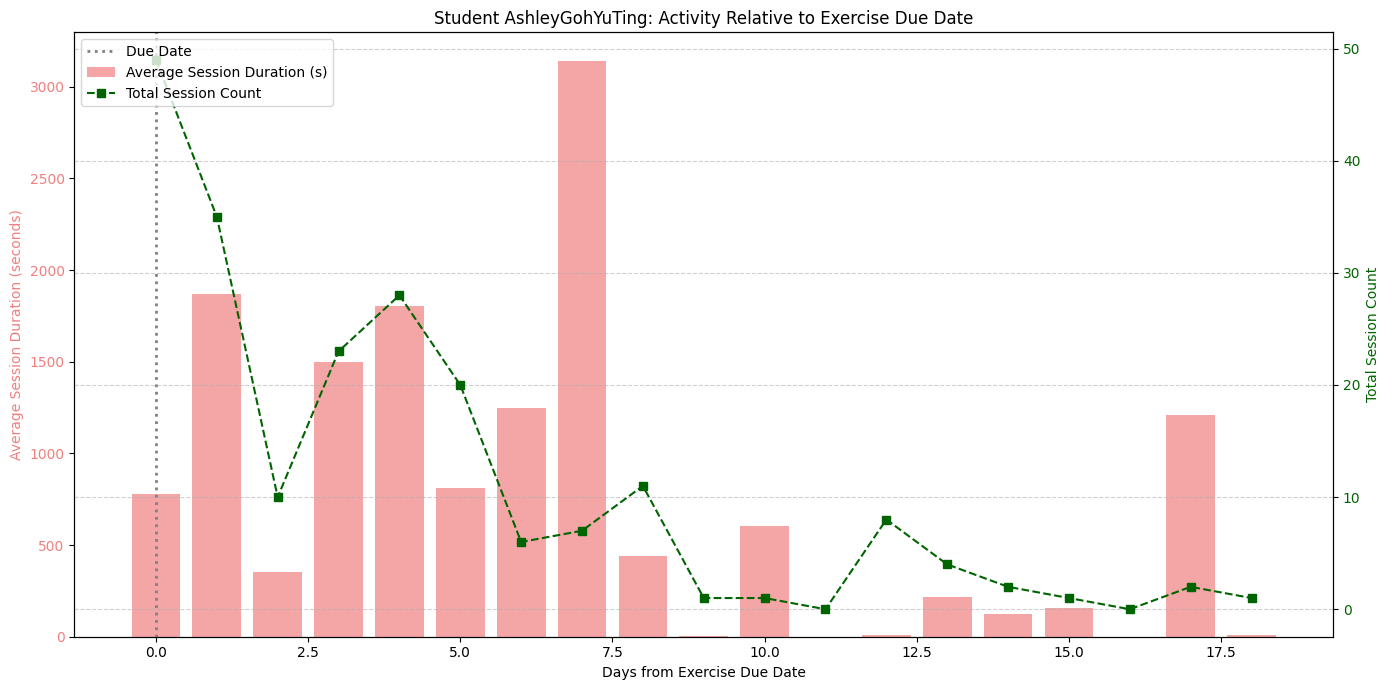

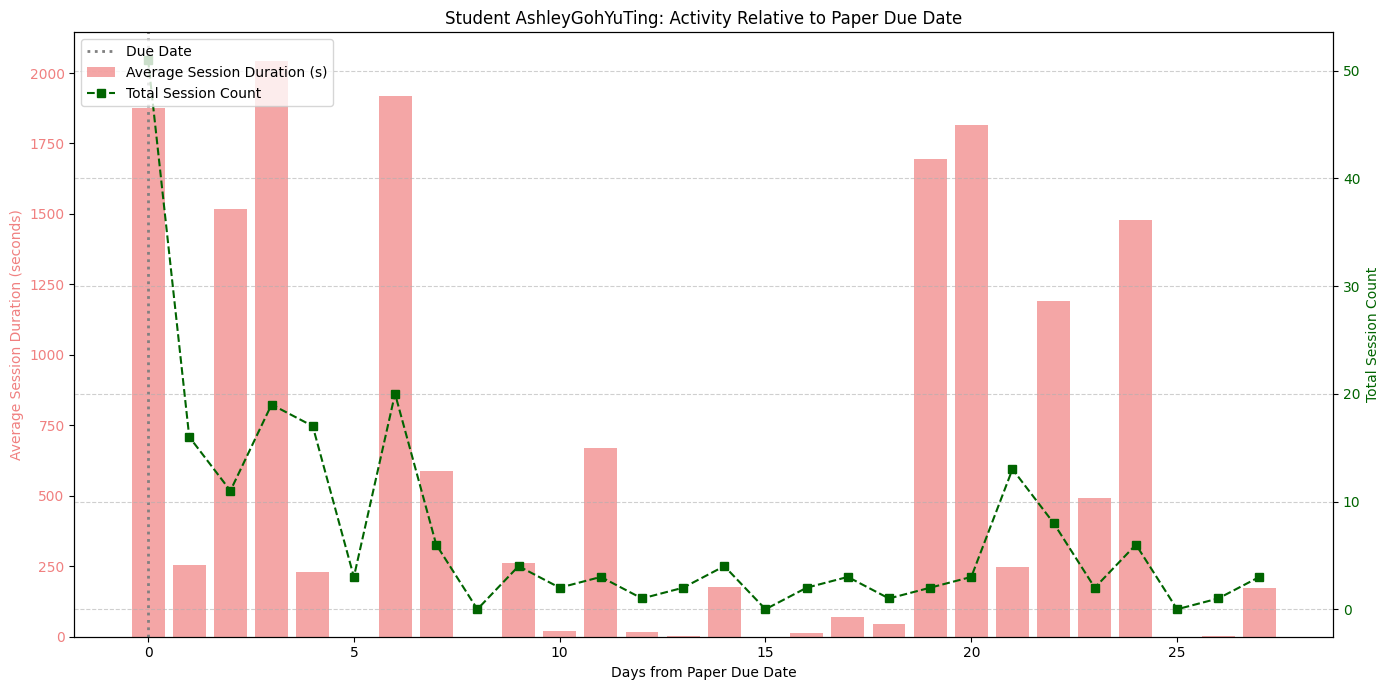

In [157]:
print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
id = input("ID of student to plot: ")
plot_due_date_activity(int(id))

## 3. Activity Trend for Specific Assignments/Students

The function `plot_student_specific_assignment_activity` visualizes how a student's activity (average session duration and session count) changes in relation to the number of days from the due date of a specific assignment.

In [167]:
# def plot_student_specific_assignment_activity(distinct_id_to_plot, assignment, specific_due_date):
#   student_data = df[df['distinct_id'] == distinct_id_to_plot]

#   if student_data.empty:
#       print(f"No data found for student with distinct_id: {distinct_id_to_plot}")
#       return

#   student_name = distinct_id_to_plot
#   if ('name' in student_data.columns):
#     student_name = student_data['name'].iloc[0]

#   due_date_col = ''
#   days_col = ''
#   assignment_label = ''

#   assignment_type = assignments_df[assignments_df['assignment_type'] == assignment]
#   if assignment_type == 'exercise':
#       due_date_col = 'next_exercise_due'
#       days_col = 'days_to_exercise_due'
#       assignment_label = 'Exercise'
#   elif assignment_type == 'paper':
#       due_date_col = 'next_paper_due'
#       days_col = 'days_to_paper_due'
#       assignment_label = 'Paper'
#   else:
#       print("Invalid assignment_type. Please choose 'Exercise' or 'Paper'.")
#       return

#   ## Filter student data for the specific assignment's due date
#   assignment_specific_data = student_data[student_data[due_date_col] == specific_due_date].copy()

#   if assignment_specific_data.empty:
#       print(f"No activity found for student {distinct_id_to_plot} for {assignment_label} due on {specific_due_date}.")
#       return

#   ## Plot session duration + session count for chosen assignment/student
#   plot(assignment_specific_data, student_name, days_col, f"{assignment_label} due {specific_due_date}")


In [168]:
# print(f'List of available students:\n {students_df.sort_values(by='distinct_id')}\n')
# student_id_input = input("Enter the distinct_id of the student to plot: ")
# print(f'\nList of available assignments:\n {assignments_df}\n')
# selected_assignment = input("Enter the name of the assignment you want to plot (from the list): ")

# try:
#   student_id = int(student_id_input)
# except ValueError:
#   print("Invalid input. Enter a valid student ID.")

# try:
#   selected_assignment_due_date = assignments_df[assignments_df['assignment'] == selected_assignment]['due_date'].iloc[0]
# except ValueError:
#   print("Invalid input. Enter a valid assignment name.")

# plot_student_specific_assignment_activity(student_id, selected_assignment, selected_assignment_due_date)
